# **Notebook 9 – Categorical Data Analysis**

In [33]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [34]:
# Load dataset
df = pd.read_csv("loan_approval_dataset.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2600 entries, 0 to 2599
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   LoanID             2600 non-null   object
 1   Age                2600 non-null   int64 
 2   Gender             2600 non-null   object
 3   Married            2600 non-null   object
 4   Dependents         2600 non-null   object
 5   Education          2600 non-null   object
 6   SelfEmployed       2600 non-null   object
 7   EmploymentType     2600 non-null   object
 8   CreditHistory      2600 non-null   object
 9   PropertyArea       2600 non-null   object
 10  LoanPurpose        2600 non-null   object
 11  LoanTermMonths     2600 non-null   int64 
 12  ApplicantIncome    2600 non-null   int64 
 13  CoapplicantIncome  2600 non-null   int64 
 14  LoanAmount         2600 non-null   int64 
 15  LoanStatus         2600 non-null   object
dtypes: int64(5), object(11)
memory usage: 325.

## **1. Unique Categories**



**Understand the Concept**

Unique categories are the different distinct values present in a categorical column.



**Demonstrate the Concept**

In the Loan Approval Dataset, categorical columns include:

- Gender
- Married
- Education
- EmploymentType
- CreditHistory
- PropertyArea
- LoanPurpose
- LoanStatus

We can identify the unique categories present in each column.

**Real-Life Example**

The Gender column may contain categories such as Male and Female.

The LoanStatus column contains Approved and Rejected.

**AI/ML Usage**

Identifying unique categories helps understand categorical features before encoding them for Machine Learning models.

In [35]:
# categorical columns
categorical_columns = df.select_dtypes(include="object").columns

In [36]:
# unique categories
for column in categorical_columns:
    print(f"{column}:",df[column].unique())

LoanID: ['LOAN00001' 'LOAN00002' 'LOAN00003' ... 'LOAN02598' 'LOAN02599'
 'LOAN02600']
Gender: ['Female' 'Male']
Married: ['No' 'Yes']
Dependents: ['1' '0' '2' '3+']
Education: ['Graduate' 'Not Graduate']
SelfEmployed: ['No' 'Yes']
EmploymentType: ['Salaried' 'Business Owner' 'Government' 'Freelancer' 'Unemployed']
CreditHistory: ['Good' 'Poor' 'Average']
PropertyArea: ['Semiurban' 'Rural' 'Urban']
LoanPurpose: ['Personal' 'Vehicle' 'Home' 'Education' 'Medical' 'Business']
LoanStatus: ['Approved' 'Rejected']


**Interpretation**

- The output shows the unique categories in each categorical column.
- This helps understand the structure of categorical data.

## **2. Category Frequencies**



**Understand the Concept**

Category frequency shows how many times each category appears in a categorical column.



**Demonstrate the Concept**

We can count the number of observations in each category.

**Real-Life Example**

LoanStatus frequency shows how many loan applications were Approved and Rejected.

**AI/ML Usage**

Category frequencies help identify dominant and less common categories before encoding and model building.

In [37]:
#  category frequencies
for column in categorical_columns:
    print("\n",df[column].value_counts())


 LoanID
LOAN00001    1
LOAN01747    1
LOAN01729    1
LOAN01730    1
LOAN01731    1
            ..
LOAN00869    1
LOAN00870    1
LOAN00871    1
LOAN00872    1
LOAN02600    1
Name: count, Length: 2600, dtype: int64

 Gender
Male      1363
Female    1237
Name: count, dtype: int64

 Married
Yes    1634
No      966
Name: count, dtype: int64

 Dependents
0     1208
1      604
2      478
3+     310
Name: count, dtype: int64

 Education
Graduate        1854
Not Graduate     746
Name: count, dtype: int64

 SelfEmployed
No     2195
Yes     405
Name: count, dtype: int64

 EmploymentType
Salaried          1133
Business Owner     547
Government         476
Freelancer         324
Unemployed         120
Name: count, dtype: int64

 CreditHistory
Good       1654
Average     677
Poor        269
Name: count, dtype: int64

 PropertyArea
Urban        980
Semiurban    924
Rural        696
Name: count, dtype: int64

 LoanPurpose
Home         889
Business     491
Education    395
Personal     363
Vehicle    

**Interpretation**

- The output shows the number of observations in each category.
- Higher counts represent more common categories.
- Lower counts represent less common categories.

## **3. Category Distribution**



**Understand the Concept**

Category distribution shows the percentage of observations in each category.



**Demonstrate the Concept**

We can calculate the percentage distribution of categories.

**Real-Life Example**

LoanStatus distribution shows the percentage of Approved and Rejected loan applications.

**AI/ML Usage**

Category distribution helps identify dominant categories and potential category imbalance.

In [38]:
# category percentage distribution

for column in categorical_columns:
    print("\n",(df[column].value_counts(normalize=True) * 100).round(2))


 LoanID
LOAN00001    0.04
LOAN01747    0.04
LOAN01729    0.04
LOAN01730    0.04
LOAN01731    0.04
             ... 
LOAN00869    0.04
LOAN00870    0.04
LOAN00871    0.04
LOAN00872    0.04
LOAN02600    0.04
Name: proportion, Length: 2600, dtype: float64

 Gender
Male      52.42
Female    47.58
Name: proportion, dtype: float64

 Married
Yes    62.85
No     37.15
Name: proportion, dtype: float64

 Dependents
0     46.46
1     23.23
2     18.38
3+    11.92
Name: proportion, dtype: float64

 Education
Graduate        71.31
Not Graduate    28.69
Name: proportion, dtype: float64

 SelfEmployed
No     84.42
Yes    15.58
Name: proportion, dtype: float64

 EmploymentType
Salaried          43.58
Business Owner    21.04
Government        18.31
Freelancer        12.46
Unemployed         4.62
Name: proportion, dtype: float64

 CreditHistory
Good       63.62
Average    26.04
Poor       10.35
Name: proportion, dtype: float64

 PropertyArea
Urban        37.69
Semiurban    35.54
Rural        26.77
Name

**Interpretation**

- The output shows the percentage of observations in each category.

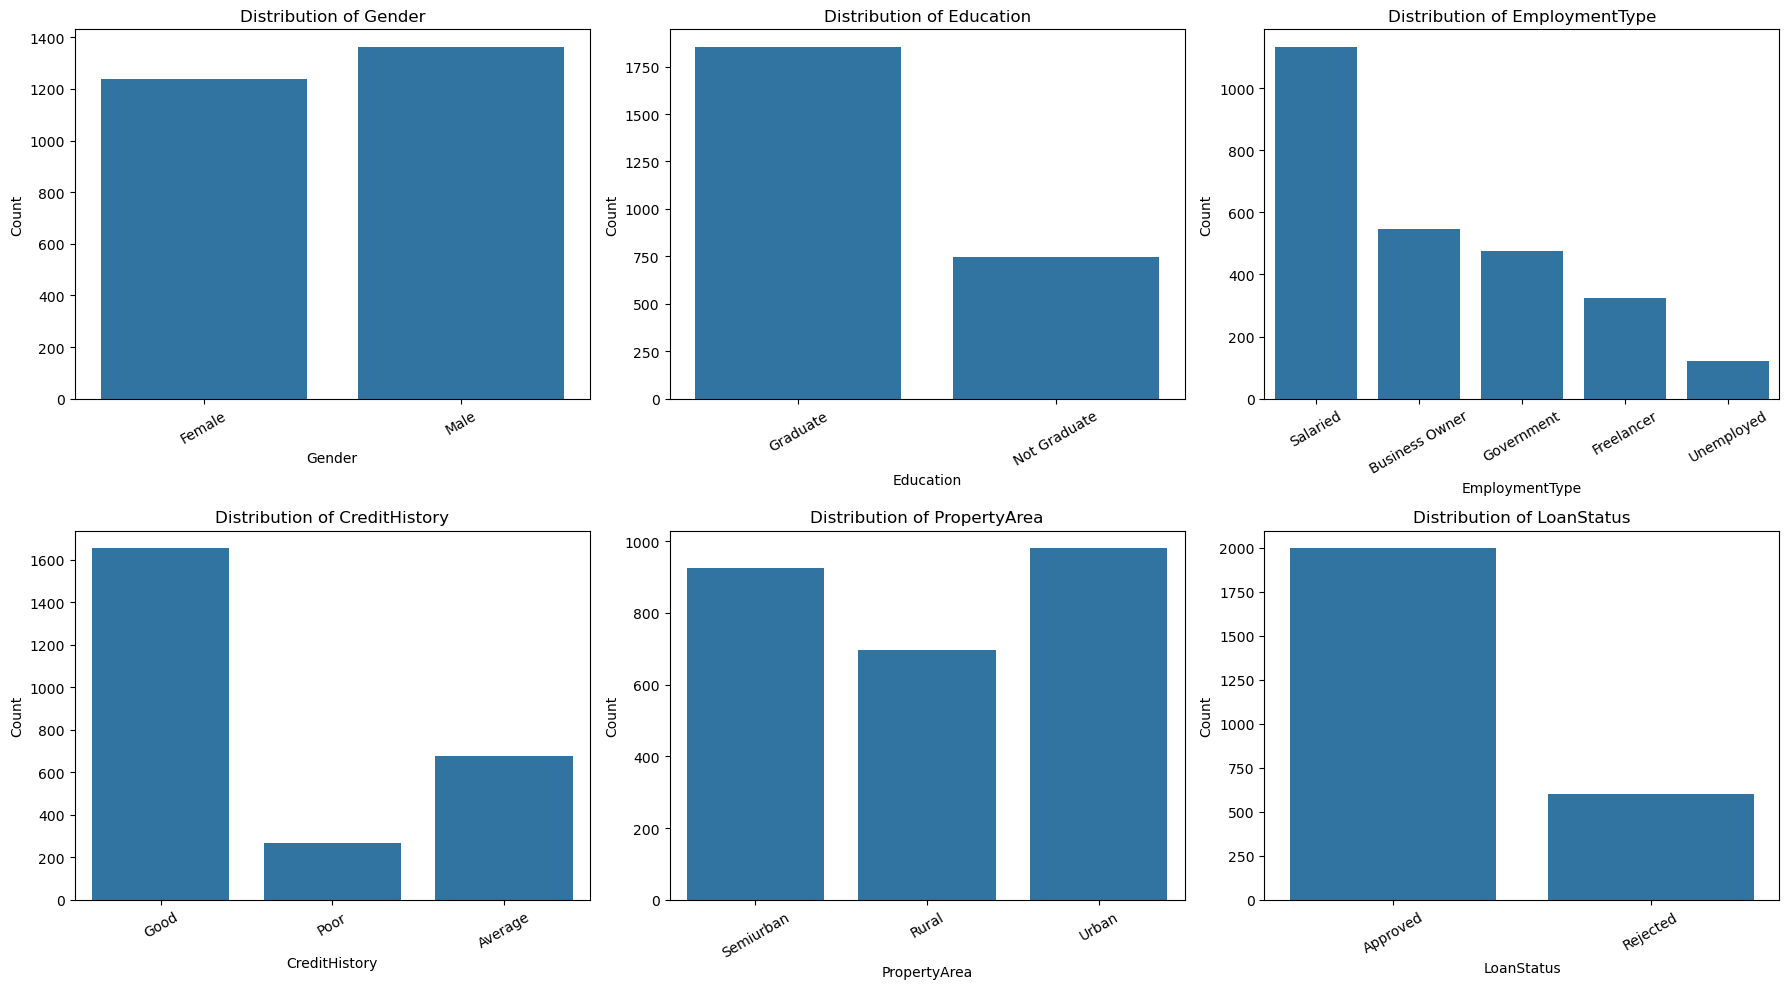

In [39]:
# multiple categorical column distributions:
columns = ["Gender", "Education", "EmploymentType", "CreditHistory","PropertyArea","LoanStatus"]
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
# Flatten axes for easy iteration
axes = axes.flatten()
for i, column in enumerate(columns):
    sns.countplot(data=df, x=column, ax=axes[i])    
    axes[i].set_title(f"Distribution of {column}")
    axes[i].set_xlabel(column)
    axes[i].set_ylabel("Count")
    axes[i].tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

**Interpretation**

- The visualizations show the distribution of multiple categorical variables.
- Taller bars represent more common categories.
- Shorter bars represent less common categories.
- The charts help identify dominant, rare, and potentially imbalanced categories.

## **4. Rare Categories**



**Understand the Concept**

Rare categories are categories that appear only a small number of times in a dataset.



**Demonstrate the Concept**

We can identify categories with a frequency below a selected threshold.

In this dataset, LoanPurpose or EmploymentType may contain less common categories.

**Real-Life Example**

If Medical appears much less frequently than Home or Business in LoanPurpose, it can be considered a rare category.

**AI/ML Usage**

Rare categories can cause problems during encoding and model training. They may be grouped into an Other category when appropriate.

In [40]:
# rare category threshold
threshold = 0.05

# category frequency
freq = df["LoanPurpose"].value_counts(normalize=True)

In [41]:
# rare categories
rare_cats = freq[freq < threshold].index

# Group rare categories as Other
df["LoanPurpose_Grouped"] = df["LoanPurpose"].replace(rare_cats,"Other")
print(df["LoanPurpose_Grouped"].value_counts())

LoanPurpose_Grouped
Home         889
Business     491
Education    395
Personal     363
Vehicle      317
Medical      145
Name: count, dtype: int64


**Interpretation**

- Categories with less than 5% frequency are considered rare.
- Rare categories are grouped into Other.

## **5. High Cardinality**



**Understand the Concept**

High cardinality means a categorical column contains a large number of unique categories.



**Demonstrate the Concept**

We can calculate the number of unique values in each categorical column.

LoanID has high cardinality because each loan application has a unique ID.

**Real-Life Example**

A CustomerID or LoanID column usually has one unique value for each record.

**AI/ML Usage**

High-cardinality features can create too many variables during encoding. Identifier columns such as LoanID are usually removed before model training.

In [42]:
# unique values in categorical columns
categorical_columns = df.select_dtypes(include="object").columns

for column in categorical_columns:
    unique_count = df[column].nunique()    
    print(f"{column} : {unique_count} unique categories")

LoanID : 2600 unique categories
Gender : 2 unique categories
Married : 2 unique categories
Dependents : 4 unique categories
Education : 2 unique categories
SelfEmployed : 2 unique categories
EmploymentType : 5 unique categories
CreditHistory : 3 unique categories
PropertyArea : 3 unique categories
LoanPurpose : 6 unique categories
LoanStatus : 2 unique categories
LoanPurpose_Grouped : 6 unique categories


In [43]:
# high-cardinality columns
threshold = 20
high_cardinality = [column for column in categorical_columns if df[column].nunique() > threshold]
print("High Cardinality Columns:")
print(high_cardinality)

High Cardinality Columns:
['LoanID']


**Interpretation**

- Columns with many unique values have high cardinality.
- LoanID is a high-cardinality identifier column.

## **6. Low Cardinality**



**Understand the Concept**

Low cardinality means a categorical column contains only a small number of unique categories.



**Demonstrate the Concept**

In the Loan Approval Dataset, columns such as Gender, Married, Education, and LoanStatus have a small number of categories.

**Real-Life Example**

The Gender column contains only Male and Female, so it has low cardinality.

**AI/ML Usage**

Low-cardinality features are usually easy to encode using techniques such as Label Encoding or One-Hot Encoding.

In [44]:
# low-cardinality columns
threshold = 10
low_cardinality = [column for column in categorical_columns if df[column].nunique() <= threshold and column != "LoanID"]
print("Low Cardinality Columns:")
print(low_cardinality)

Low Cardinality Columns:
['Gender', 'Married', 'Dependents', 'Education', 'SelfEmployed', 'EmploymentType', 'CreditHistory', 'PropertyArea', 'LoanPurpose', 'LoanStatus', 'LoanPurpose_Grouped']


**Interpretation**

- Low-cardinality columns contain only a few unique categories.
- Gender, Married, Education, and LoanStatus are examples of low-cardinality features.

## **7. Category Imbalance**



**Understand the Concept**

Category imbalance occurs when some categories have significantly more observations than others.



**Demonstrate the Concept**

We can analyze the distribution of the target variable, LoanStatus, to check whether Approved and Rejected applications are balanced.

**Real-Life Example**

If Approved applications are much more common than Rejected applications, the target variable is imbalanced.

**AI/ML Usage**

Category imbalance can affect Machine Learning models because the model may become biased toward the majority class.

In [45]:
# category imbalance in LoanStatus
loan_status_counts = df["LoanStatus"].value_counts()
loan_status_percentage = (df["LoanStatus"].value_counts(normalize=True).mul(100).round(2))
print("Category Counts:")
print(loan_status_counts)

print("\nCategory Percentage:")
print(loan_status_percentage)

Category Counts:
LoanStatus
Approved    1998
Rejected     602
Name: count, dtype: int64

Category Percentage:
LoanStatus
Approved    76.85
Rejected    23.15
Name: proportion, dtype: float64


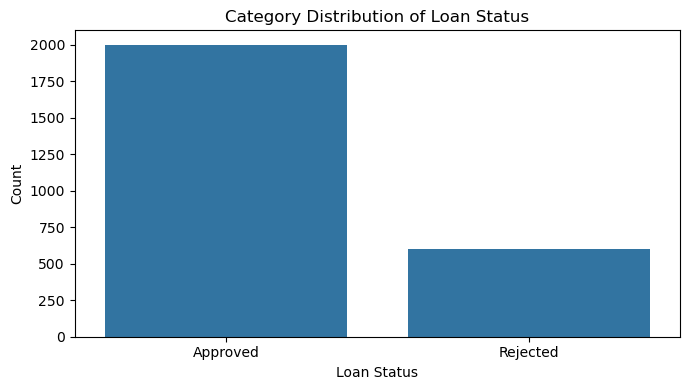

In [46]:
# Visualize category imbalance
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x="LoanStatus")
plt.title("Category Distribution of Loan Status")
plt.xlabel("Loan Status")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

**Interpretation**

- The chart shows the distribution of Approved and Rejected loans.
- A large difference between the categories indicates category imbalance.
- Imbalanced target data may require techniques such as class weighting or resampling.